<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/10_lr_schedules_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10. Learning-Rate Schedules — Keras

The learning rate is arguably the single most important hyperparameter. Instead of a fixed value, a **schedule** lowers it over training — fast early progress, then fine settling. We compare **Constant, Step decay, Exponential decay, and ReduceLROnPlateau**.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Define the schedules

The first three are deterministic functions of the epoch (used via a `LearningRateScheduler` callback). `ReduceLROnPlateau` is *adaptive* — it cuts the LR only when the validation loss stalls.

In [5]:
import math

EPOCHS = 120
BASE_LR = 0.1

def make_model():
    keras.utils.set_random_seed(42)
    m = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.SGD(BASE_LR),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

# deterministic schedules: LR as a function of epoch
def constant(epoch, lr):   return BASE_LR
def step_decay(epoch, lr): return BASE_LR * (0.5 ** (epoch // 30))     # halve every 30 epochs
def exp_decay(epoch, lr):  return BASE_LR * math.exp(-0.03 * epoch)    # smooth exponential

det_schedules = {"Constant": constant, "Step decay": step_decay, "Exp decay": exp_decay}

## 5. Train with each schedule

For the deterministic ones we also compute the LR curve directly from the function. For `ReduceLROnPlateau` we log the optimizer's LR each epoch (it depends on the data).

In [6]:
def get_lr(opt):
    try:
        return float(keras.ops.convert_to_numpy(opt.learning_rate))
    except Exception:
        return float(opt.learning_rate)

class LRLogger(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.lrs = []
    def on_epoch_begin(self, epoch, logs=None): self.lrs.append(get_lr(self.model.optimizer))

histories, lr_curves = {}, {}

for name, fn in det_schedules.items():
    m = make_model()
    h = m.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=EPOCHS, batch_size=32, verbose=0,
              callbacks=[keras.callbacks.LearningRateScheduler(fn)])
    histories[name] = h
    lr_curves[name] = [fn(e, None) for e in range(EPOCHS)]

# adaptive schedule
m = make_model()
logger = LRLogger()
rlrop = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=10, min_lr=1e-4)
histories["ReduceLROnPlateau"] = m.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=EPOCHS, batch_size=32, verbose=0, callbacks=[rlrop, logger])
lr_curves["ReduceLROnPlateau"] = logger.lrs

for name, h in histories.items():
    print("%-18s best test acc = %.3f | final test loss = %.3f" %
          (name, max(h.history["val_accuracy"]), h.history["val_loss"][-1]))

Constant           best test acc = 0.862 | final test loss = 0.395
Step decay         best test acc = 0.862 | final test loss = 0.404
Exp decay          best test acc = 0.854 | final test loss = 0.410
ReduceLROnPlateau  best test acc = 0.862 | final test loss = 0.395


## 6. The schedules and their effect

Left: how each learning rate evolves (log scale). Right: the resulting test-loss curves. Notice the decaying schedules settle to a **lower, smoother** loss.

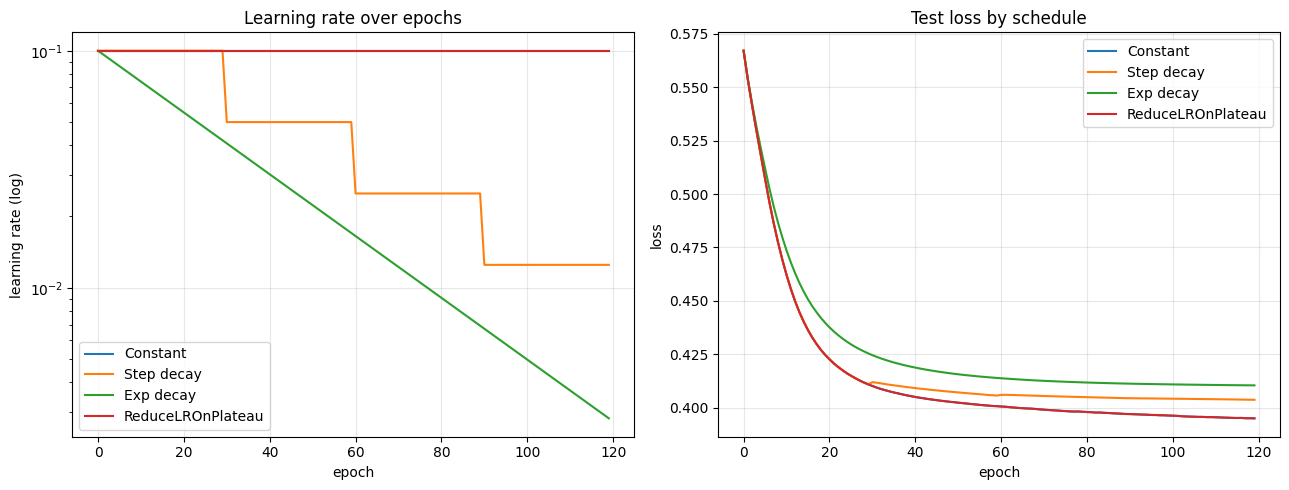

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in histories:
    ax[0].plot(lr_curves[name], label=name)
    ax[1].plot(histories[name].history["val_loss"], label=name)
ax[0].set_title("Learning rate over epochs"); ax[0].set_yscale("log")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("learning rate (log)")
ax[1].set_title("Test loss by schedule"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Summary table

In [8]:
summary = pd.DataFrame({
    name: {
        "best_test_acc":  max(h.history["val_accuracy"]),
        "final_test_loss": h.history["val_loss"][-1],
        "final_lr":       lr_curves[name][-1],
    } for name, h in histories.items()
}).T.sort_values("best_test_acc", ascending=False)
summary.round(4)

,best_test_acc,final_test_loss,final_lr
Constant,0.8618,0.3950,0.1000
Step decay,0.8618,0.4037,0.0125
ReduceLROnPlateau,0.8618,0.3950,0.1000
Exp decay,0.8537,0.4104,0.0028


## 8. Alternative API — schedule *objects*

Instead of a callback, Keras lets you pass a `keras.optimizers.schedules.*` object **directly to the optimizer**. The rate then decays per *optimizer step* (batch), not per epoch — handy when you want the schedule baked into the optimizer itself.

Schedule-object run: best test acc = 0.854 | final test loss = 0.408


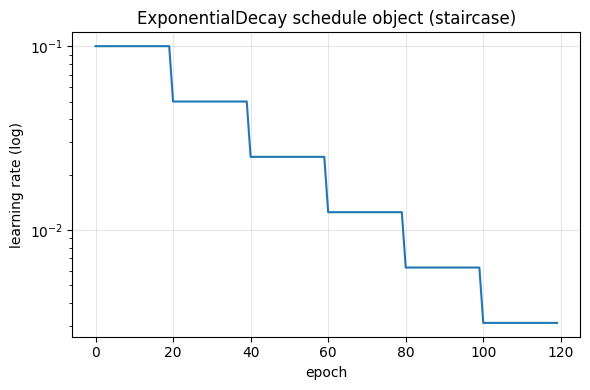

In [9]:
steps_per_epoch = int(np.ceil(len(X_train) / 32))
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=BASE_LR,
    decay_steps=steps_per_epoch * 20,   # decay every ~20 epochs
    decay_rate=0.5,                     # halve
    staircase=True,
)

keras.utils.set_random_seed(42)
m = keras.Sequential([
    keras.Input(shape=(N_FEATURES,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])
m.compile(optimizer=keras.optimizers.SGD(lr_schedule),   # schedule passed to the optimizer
          loss="binary_crossentropy", metrics=["accuracy"])
h_obj = m.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=EPOCHS, batch_size=32, verbose=0)
print("Schedule-object run: best test acc = %.3f | final test loss = %.3f" %
      (max(h_obj.history["val_accuracy"]), h_obj.history["val_loss"][-1]))

# recover the per-epoch LR for plotting
lr_obj = [float(keras.ops.convert_to_numpy(lr_schedule(step * steps_per_epoch)))
          for step in range(EPOCHS)]
plt.figure(figsize=(6, 4))
plt.plot(lr_obj); plt.yscale("log")
plt.title("ExponentialDecay schedule object (staircase)")
plt.xlabel("epoch"); plt.ylabel("learning rate (log)"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- A **constant** high LR keeps bouncing near the minimum — the loss stays noisy and never fully settles.
- **Step / exponential decay** start fast (large LR) then shrink the steps, letting the model fine-tune into a lower loss.
- **ReduceLROnPlateau** is adaptive: it only drops the LR when progress stalls, so you don't have to hand-tune the decay curve — often the most practical choice.
- Keras exposes schedules two ways: `LearningRateScheduler`/`ReduceLROnPlateau` callbacks (used here) or `keras.optimizers.schedules.*` objects passed straight to the optimizer.
- Pairs with `04_early_stopping_keras` — schedules and early stopping are complementary knobs on *when and how fast* you train.